# Silicon sampling Tutorial: can we simulate migration opinion?
**Instructor:** [Germán Rosati](https://gefero.github.io)

Here is some code to test simulations using [Wold Value Survey]() data.



## WVS Wave 7 — Silicon Sampling v2

**Experimental Design**
- Profile variables: country, sex, education, class, occupation, political ideology (`political_ident`)
- 4 independent calls per row — one per question
- Each call receives only the profile, no context from other responses
- 3 system prompts differentiated by question type

| Call | Question | Type | System prompt |
|---|---|---|---|
| 1 | Q121 | Ordinal evaluation (1–5) | A |
| 2 | Q122 | Agreement/disagreement | B |
| 3 | Q128 | Agreement/disagreement | B |
| 4 | Q130 | Policy choice | C |

- **Countries**: Argentina · Uruguay · United States
- **Backends**: OpenAI API · Ollama (local

## Deploying local LLMs using ollama

The ecosystem of large language models (LLMs) has grown exponentially in recent years, and today there are multiple ways to interact with these models. One of the most interesting alternatives for those seeking autonomy, privacy, and efficiency is [**Ollama**](https://ollama.com/), a framework that allows running language models **locally**, without the need for connection to external servers or cloud service subscriptions.

<img src = https://ollama.com/public/new.png svg.png width = "500" height = "400" >

### Main advantages of using Ollama

**1. Data privacy and control**
When you use an LLM through an API (like OpenAI, Anthropic, or Google), your data travels to external servers. Although these platforms usually offer confidentiality guarantees, in sensitive environments—such as academic research, journalism, healthcare, or business projects—it can be crucial to avoid any unnecessary exposure of information. With Ollama, all processing occurs on your own machine, ensuring greater control over data and minimizing risks.

**2. Zero token or usage costs**
Cloud APIs are generally billed by processed tokens, which can become costly as projects scale or more intensive tasks are performed. Ollama, on the other hand, allows running free models (or open-source models with permissive licenses) directly from your computer, without paying for each query.

**3. Works offline**
Once the model is downloaded, Ollama can work **completely offline**, which is especially useful in contexts with limited connectivity, field situations, or environments isolated from the digital world.

**4. Ease of use and setup**
Ollama offers a simple and consistent interface for running different models (such as LLaMA 3, Mistral, Phi, Gemma, among others), with simple commands like `ollama run mistral`. It automatically handles downloading, configuring, and running the model, without the need for manual configuration of complex inference environments.

**5. Access to customizable and open-source models**
With Ollama, you can load open-source models and **fine-tune them with your own instructions or datasets**, allowing for deeper customization without relying on restrictions imposed by commercial platforms. In addition, its integration with other tools like LangChain or RAG pipelines facilitates the construction of conversational agents or local assistants.

Furthermore, there is a final aspect to consider: many LLMs that are "smaller" in terms of the number of parameters exhibit similar performance to larger ones.

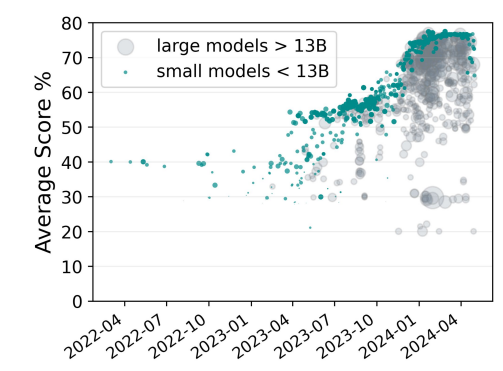

If you are interested in delving into this last issue, [here](https://www.youtube.com/watch?v=PMYhI0K_508&t=139s) is a conference given by Sara Hooker this year. [Here](https://arxiv.org/abs/2407.05694v1), furthermore, there is a paper.

But first we need to install `Ollama`. In this tutorial we are going to do the installation on Linux, but in case you use another operating system, here are some useful links.

**Windows**
- [installer](https://ollama.com/download/windows)
- [video tutorial](https://www.youtube.com/watch?v=3W-trR0ROUY)

**Mac**
- [installer](https://ollama.com/download/mac)
- [video tutorial](https://www.youtube.com/watch?v=Og7B1bw-h_0)

All right, let's get to it.

The first thing we need to do is download Ollama:

In [ ]:
## TO USE OLLAMA
!pip install ollama
!sudo apt-get install zstd
!curl -fsSL https://ollama.com/install.sh | sh

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 1s (1,048 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 118243 files and directories currently 

If we wanted to use the OpenAI API, we could install...

In [ ]:
# TO USE OPENAI
#!pip install openai

Just in case...

In [ ]:
!pip install pandas matplotlib seaborn tqdm

Now, let's clone the repo with all the data.

In [ ]:
!git clone https://github.com/gefero/factor_data_silicon_tutorial.git

Cloning into 'factor_data_silicon_tutorial'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 14 (delta 4), reused 14 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 2.73 MiB | 5.99 MiB/s, done.
Resolving deltas: 100% (4/4), done.


## 1. Configuration

In [ ]:
import json
import os
import re
import time
from datetime import datetime
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Principal parameters ──────────────────────────────────────────────────
BACKEND     = "ollama"       # "openai" | "ollama"
MODEL       = "gpt-oss:120B"       # openai: "gpt-4o", "gpt-4o-mini", "gpt-4.1"
                              # ollama: "gpt-oss:20b", "llama3.1", etc.
TEMPERATURE = 1.0

COUNTRIES   = ["Argentina", "Uruguay", "United States"]

# N_SAMPLE: rows per country
#   None  → all valid rows in the country
#   int   → n size stratified random sample
# Note: with 4 reqs per row and  N_SAMPLE=50 → 600 total reqs
N_SAMPLE    = None
RANDOM_SEED = 42

# Pause bewtween reqs (secs)
# OpenAI: 0.5 to avoid evitar rate-limit | Ollama: 0
SLEEP = 0.5

# Question to simulate in this run
# Options: "Q121" | "Q122" | "Q128" | "Q130"
QUESTION = "Q130"


DATA_PATH  = "/content/factor_data_silicon_tutorial/input_data/WVS_wave7_migracion_prompts.csv"
OUTPUT_CSV = "/content/factor_data_silicon_tutorial/output_data/" + MODEL + "_" + QUESTION + "_v2_WVS_silicon_empirico_results.csv"


print(f"Backend   : {BACKEND}")
print(f"Model    : {MODEL}")
print(f"Countries    : {COUNTRIES}")
n_rows = N_SAMPLE * len(COUNTRIES) if N_SAMPLE else 'todas'
n_calls = N_SAMPLE * len(COUNTRIES) * 4 if N_SAMPLE else 'todas × 4'
print(f"Rows     : {n_rows}")
print(f"Question  : {QUESTION}")
print(f"Reqs  : {n_rows} (1 por fila)")

Backend   : ollama
Model    : gpt-oss:120B
Countries    : ['Argentina', 'Uruguay', 'United States']
Rows     : todas
Question  : Q130
Reqs  : todas (1 por fila)


## 2. Import and filter file with empirical information

In [ ]:
Q121_VALID = {
    "Very good",
    "Quite good",
    "Neither good, nor bad",
    "Quite bad",
    "Rather bad",
}

Q122_VALID = {"Agree", "Hard to say", "Disagree"}
Q128_VALID = {"Agree", "Hard to say", "Disagree"}

Q130_VALID = {
    "Let anyone come who wants to",
    "Let people come as long as there are jobs available",
    "Place strict limits on the number of foreigners who can come here",
    "Prohibit people coming here from other countries",
}

df_raw = pd.read_csv(DATA_PATH)
print(f"Total rows in archive: {len(df_raw):,}")

df = df_raw[
    df_raw["B_COUNTRY_LABEL"].isin(COUNTRIES)
    & df_raw["Q121"].isin(Q121_VALID)
    & df_raw["Q122"].isin(Q122_VALID)
    & df_raw["Q128"].isin(Q128_VALID)
    & df_raw["Q130"].isin(Q130_VALID)
    & df_raw["political_ident"].notna()
].copy()

print(f"\nValid rows per country:")
print(df["B_COUNTRY_LABEL"].value_counts().to_string())

if N_SAMPLE is not None:
    df = (
        df.groupby("B_COUNTRY_LABEL", group_keys=False)
        .apply(lambda g: g.sample(min(N_SAMPLE, len(g)), random_state=RANDOM_SEED))
        .reset_index(drop=True)
    )
    print(f"\nAfter sampling ({N_SAMPLE} per country):")
    print(df["B_COUNTRY_LABEL"].value_counts().to_string())

print(f"\nTotal rows to process: {len(df)}")
print(f"Total reqs to make: {len(df) * 4}")
df.head(3)

Total filas en el archivo : 59,868

Filas válidas por país:
B_COUNTRY_LABEL
United States    1457
Uruguay           751
Argentina         681

Total de filas a procesar: 2889
Total de llamadas        : 11556


,id,B_COUNTRY_LABEL,sex_label,education_label,class_label,occupation_label,political_ident,Q130,Q121,Q122,Q128,Q34,Q63,Q263,Q272,Q269
884,1005,Argentina,man,secondary education,lower middle class,skilled worker,center,Place strict limits on the number of foreigner...,Rather bad,Agree,Agree,Agree,Trust somewhat,I am born in this country,Spanish; Castilian,Yes
885,1007,Argentina,man,secondary education,lower middle class,skilled worker,center-right,Place strict limits on the number of foreigner...,Quite good,Agree,Disagree,Neither agree nor disagree,Don't know,I am born in this country,Spanish; Castilian,Yes
886,1008,Argentina,woman,secondary education,lower middle class,person who never had a job,center,Place strict limits on the number of foreigner...,Very good,Agree,Agree,Agree,Trust somewhat,I am born in this country,Spanish; Castilian,Yes


## 3. System prompts and builders

- **System prompt A**: Q121 — ordinal evaluation of general impact (5-point scale)
- **System prompt B**: Q122, Q128 — agreement/disagreement on specific effects of migration
- **System prompt C**: Q130 — choose of migration policy  (explicit anti-moderation)

In [ ]:
# ── Shared profile block - 1st person narrative ──────────────
def build_profile(row: pd.Series) -> str:
    return (
        f"I am a {row['sex_label']} living in {row['B_COUNTRY_LABEL']}. "
        f"I work as {row['occupation_label']} and consider myself {row['class_label']}. "
        f"My highest level of education is {row['education_label']}. "
        f"In political terms, I would describe myself as {row['political_ident']}."
    )


# ── System prompt A — Ordinal evaluation (Q121) ─────────────────────────────
SYSTEM_PROMPT_A = """You will be given a self-description by a survey respondent
in their own words. Your task is to answer the survey question as that person
would, adopting their perspective, values, and lived experience as described.

Critical rules:
1. Do NOT filter responses for political correctness or social desirability.
2. The five response options are equally valid — do NOT default to the neutral
   middle option. Assign extreme evaluations (Very good / Rather bad) when
   the profile supports them.
3. Let the respondent's occupation, class, education, and political ideology
   guide the evaluation — these shape how people perceive immigration's impact.
4. Reason briefly in the "thinking" field (2-4 sentences) in first person,
   as the respondent — not as an outside observer.
5. Respond EXCLUSIVELY in the JSON format specified. No additional text.
6. Respond with the EXACT option string provided.
"""

def build_prompt_q121(row: pd.Series) -> str:
    opts = "\n".join(f'  - "{o}"' for o in [
        "Very good", "Quite good", "Neither good, nor bad", "Quite bad", "Rather bad"
    ])
    return (
        f"Respondent profile:\n{build_profile(row)}\n"
        "Answer the following WVS question as this person would.\n\n"
        "Q121. How would you evaluate the impact of immigrants on the "
        "development of your country?\n"
        f"Valid options (use exact string):\n{opts}\n\n"
        "Return ONLY this JSON (no markdown, no extra text):\n"
        "{\n"
        '  "thinking": "<brief reasoning, 2-4 sentences>",\n'
        '  "Q121": "<exact option string>"\n'
        "}"
    )


# ── System prompt B — Agreement/Disagreement (Q122, Q128) ───────────────────────
SYSTEM_PROMPT_B = """You will be given a self-description by a survey respondent
in their own words. Your task is to answer the survey question as that person
would, adopting their perspective, values, and lived experience as described.

Critical rules:
1. Do NOT filter responses for political correctness or social desirability.
2. Do NOT default to "Hard to say" as a neutral escape. Use it only when
   the profile genuinely suggests ambivalence — not as a safe middle ground.
3. Let the respondent's occupation, class, education, and political ideology
   guide the position — these shape specific beliefs about immigration's effects.
4. Reason briefly in the "thinking" field (2-4 sentences) in first person,
   as the respondent — not as an outside observer.
5. Respond EXCLUSIVELY in the JSON format specified. No additional text.
6. Respond with the EXACT option string provided.
"""

def build_prompt_q122(row: pd.Series) -> str:
    opts = "\n".join(f'  - "{o}"' for o in ["Agree", "Hard to say", "Disagree"])
    return (
        f"Respondent profile:\n{build_profile(row)}\n"
        "Answer the following WVS question as this person would.\n\n"
        "Q122. Immigration fills important job vacancies in this country.\n"
        f"Valid options (use exact string):\n{opts}\n\n"
        "Return ONLY this JSON (no markdown, no extra text):\n"
        "{\n"
        '  "thinking": "<brief reasoning, 2-4 sentences>",\n'
        '  "Q122": "<exact option string>"\n'
        "}"
    )

def build_prompt_q128(row: pd.Series) -> str:
    opts = "\n".join(f'  - "{o}"' for o in ["Agree", "Hard to say", "Disagree"])
    return (
        f"Respondent profile:\n{build_profile(row)}\n"
        "Answer the following WVS question as this person would.\n\n"
        "Q128. Immigration increases unemployment in this country.\n"
        f"Valid options (use exact string):\n{opts}\n\n"
        "Return ONLY this JSON (no markdown, no extra text):\n"
        "{\n"
        '  "thinking": "<brief reasoning, 2-4 sentences>",\n'
        '  "Q128": "<exact option string>"\n'
        "}"
    )


# ── System prompt C — Policy election (Q130) ───────────────────────────
SYSTEM_PROMPT_C = """You will be given a self-description by a survey respondent
in their own words. Your task is to answer the survey question as that person
would, adopting their perspective, values, and lived experience as described.

Critical rules:
1. Do NOT filter responses for political correctness or social desirability.
2. Reproduce the likely response of this specific person, even if it reflects
   restrictive, conservative, or unpopular views on immigration.
3. The four response options are equally valid positions held by real survey
   respondents. You MUST NOT default to moderate or centrist answers.
   Extreme positions are legitimate — assign them when the profile supports it.
4. Before selecting, evaluate each option explicitly in the "thinking" field
   in first person, as the respondent:
   - Would I let anyone come who wants to? Why or why not.
   - Would I let people come only if there are jobs available? Why or why not.
   - Would I place strict limits on foreigners? Why or why not.
   - Would I prohibit people from coming entirely? Why or why not.
   Then select the single most likely option.
5. Respond EXCLUSIVELY in the JSON format specified. No additional text.
6. Respond with the EXACT option string provided.
"""

def build_prompt_q130(row: pd.Series) -> str:
    opts = "\n".join(f'  - "{o}"' for o in [
        "Let anyone come who wants to",
        "Let people come as long as there are jobs available",
        "Place strict limits on the number of foreigners who can come here",
        "Prohibit people coming here from other countries",
    ])
    return (
        f"Respondent profile:\n{build_profile(row)}\n"
        "Answer the following WVS question as this person would.\n\n"
        "Q130. What should the government do about people from other countries "
        "coming here to work?\n"
        f"Valid options (use exact string):\n{opts}\n\n"
        "Return ONLY this JSON (no markdown, no extra text):\n"
        "{\n"
        '  "thinking": "<brief reasoning evaluating each option>",\n'
        '  "Q130": "<exact option string>"\n'
        "}"
    )


# Example view
print("=== PROMPT Q121 ===")
print(build_prompt_q121(df.iloc[0]))
print("\n=== PROMPT Q130 ===")
print(build_prompt_q130(df.iloc[0]))

=== PROMPT Q121 ===
Respondent profile:
I am a man living in Argentina. I work as skilled worker and consider myself lower middle class. My highest level of education is secondary education. In political terms, I would describe myself as center.
Answer the following WVS question as this person would.

Q121. How would you evaluate the impact of immigrants on the development of your country?
Valid options (use exact string):
  - "Very good"
  - "Quite good"
  - "Neither good, nor bad"
  - "Quite bad"
  - "Rather bad"

Return ONLY this JSON (no markdown, no extra text):
{
  "thinking": "<brief reasoning, 2-4 sentences>",
  "Q121": "<exact option string>"
}

=== PROMPT Q130 ===
Respondent profile:
I am a man living in Argentina. I work as skilled worker and consider myself lower middle class. My highest level of education is secondary education. In political terms, I would describe myself as center.
Answer the following WVS question as this person would.

Q130. What should the government d

## 4. Parsing & validation

In [ ]:
def parse_response(raw: str) -> dict:
    raw = raw.strip()
    raw = re.sub(r"^```(?:json)?\s*", "", raw, flags=re.IGNORECASE)
    raw = re.sub(r"\s*```$", "", raw)
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        m = re.search(r"\{.*\}", raw, re.DOTALL)
        if m:
            try:
                return json.loads(m.group())
            except json.JSONDecodeError:
                pass
    return {}


def validate_q121(p): return p.get("Q121") in Q121_VALID
def validate_q122(p): return p.get("Q122") in Q122_VALID
def validate_q128(p): return p.get("Q128") in Q128_VALID
def validate_q130(p): return p.get("Q130") in Q130_VALID

print("OK")

OK


## 5. Backends LLM

In [ ]:
def call_openai(system_prompt: str, user_prompt: str) -> tuple[dict, str]:
    from openai import OpenAI
    from google.colab import userdata
    api_key = userdata.get('key_openai')
    if not api_key:
        raise EnvironmentError("key_openai not found in Colab secrets.")
    client = OpenAI(api_key=api_key)
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_prompt},
        ],
        temperature=TEMPERATURE,
    )
    raw = resp.choices[0].message.content.strip()
    return parse_response(raw), raw


def call_ollama(system_prompt: str, user_prompt: str) -> tuple[dict, str]:
    import ollama
    resp = ollama.chat(
        model=MODEL,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_prompt},
        ],
        options={"temperature": TEMPERATURE},
    )
    raw = resp["message"]["content"].strip()
    return parse_response(raw), raw


CALL = call_openai if BACKEND == "openai" else call_ollama


# Question selector — it is configured in cell 1 with QUESTION paramater
QUESTION_CONFIG = {
    "Q121": (SYSTEM_PROMPT_A, build_prompt_q121, validate_q121),
    "Q122": (SYSTEM_PROMPT_B, build_prompt_q122, validate_q122),
    "Q128": (SYSTEM_PROMPT_B, build_prompt_q128, validate_q128),
    "Q130": (SYSTEM_PROMPT_C, build_prompt_q130, validate_q130),
}

def generate_one(row: pd.Series) -> dict:
    """One call per wor for question configured in QUESTION."""
    sys_p, usr_fn, validator = QUESTION_CONFIG[QUESTION]
    try:
        parsed, raw = CALL(sys_p, usr_fn(row))
        valid = validator(parsed)
    except Exception as e:
        parsed, raw, valid = {}, str(e), False
    return {
        "value":    parsed.get(QUESTION),
        "thinking": parsed.get("thinking", ""),
        "valid":    valid,
        "raw":      raw,
    }


print(f"Active backend : {BACKEND} → {CALL.__name__}")
print(f"Active question: {QUESTION}")

Backend activo : ollama → call_ollama
Pregunta activa: Q130


## 6. Simulation

> Incremental saving every 10 rows (= 40 calls).  
> If the kernel is interrupted, re-run this cell — it resumes automatically.

In [ ]:
from tqdm.notebook import tqdm

out_path = Path(OUTPUT_CSV)

if out_path.exists():
    df_prev  = pd.read_csv(out_path)
    done_ids = set(df_prev["empirical_id"].tolist())
    df_todo  = df[~df["id"].isin(done_ids)].copy()
    records  = df_prev.to_dict("records")
    print(f"Resuming: {len(done_ids)} processed, {len(df_todo)} pending.")
else:
    df_todo = df.copy()
    records = []
    print(f"Fresh start: {len(df_todo)} rows — question {QUESTION}.")

total = len(df_todo)

for i, (_, row) in enumerate(tqdm(df_todo.iterrows(), total=total), start=1):

    res = generate_one(row)
    q   = QUESTION.lower()

    records.append({
        # Identificadores
        "empirical_id"    : row["id"],
        "country"         : row["B_COUNTRY_LABEL"],
        "question"        : QUESTION,
        # Perfil enviado al modelo
        "sex"             : row["sex_label"],
        "education"       : row["education_label"],
        "class"           : row["class_label"],
        "occupation"      : row["occupation_label"],
        "political_ident" : row["political_ident"],
        # Ground truth empírico (solo la pregunta activa)
        "empirical"       : row[QUESTION],
        # Respuesta del modelo
        "model"           : res["value"],
        "thinking"        : res["thinking"],
        # Coincidencia
        "match"           : row[QUESTION] == res["value"],
        # Validez
        "valid"           : res["valid"],
        "raw_response"    : res["raw"],
        # Metadatos
        "backend"         : BACKEND,
        "model_name"      : MODEL,
        "temperature"     : TEMPERATURE,
        "timestamp"       : datetime.utcnow().isoformat(),
    })

    if i % 10 == 0:
        pd.DataFrame(records).to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

results = pd.DataFrame(records)
results.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
print(f"\n✅ {len(results)} rows processed → '{OUTPUT_CSV}'")

Inicio fresco: 2889 filas — pregunta Q130.


  0%|          | 0/2889 [00:00<?, ?it/s]

/tmp/ipykernel_693/2747682774.py:48: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp"       : datetime.utcnow().isoformat(),



✅ 2889 filas procesadas → '/content/drive/MyDrive/UNSAM/Factor-Data/Proyectos/LLMs_Sillicon_sampling/migraciones/gpt-oss:120B_Q130_v2_WVS_silicon_empirico_results.csv'
